# Body Performance — Neural Network (Classification)



## Cell 1 — Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Activation
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# ── Reproducibility ───────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('Libraries loaded.')
print(f'TensorFlow version: {tf.__version__}')

Libraries loaded.
TensorFlow version: 2.19.0


## Cell 2 — Load & Inspect Data

In [ ]:
def load_and_inspect(file_path):
    df = pd.read_csv(file_path)
    print("Data loaded successfully. Here's a peek at the first 5 rows:")
    display(df.head())
    print('\n--- Data Information ---')
    df.info()
    print('\n--- Descriptive Statistics ---')
    display(df.describe())
    return df

df = load_and_inspect('/content/bodyPerformance.csv')

Data loaded successfully. Here's a peek at the first 5 rows:


,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class
0,27.0,M,172.3,75.24,21.3,80.0,130.0,54.9,18.4,60.0,217.0,C
1,25.0,M,165.0,55.80,15.7,77.0,126.0,36.4,16.3,53.0,229.0,A
2,31.0,M,179.6,78.00,20.1,92.0,152.0,44.8,12.0,49.0,181.0,C
3,32.0,M,174.5,71.10,18.4,76.0,147.0,41.4,15.2,53.0,219.0,B
4,28.0,M,173.8,67.70,17.1,70.0,127.0,43.5,27.1,45.0,217.0,B



--- Data Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13393 entries, 0 to 13392
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      13393 non-null  float64
 1   gender                   13393 non-null  object 
 2   height_cm                13393 non-null  float64
 3   weight_kg                13393 non-null  float64
 4   body fat_%               13393 non-null  float64
 5   diastolic                13393 non-null  float64
 6   systolic                 13393 non-null  float64
 7   gripForce                13393 non-null  float64
 8   sit and bend forward_cm  13393 non-null  float64
 9   sit-ups counts           13393 non-null  float64
 10  broad jump_cm            13393 non-null  float64
 11  class                    13393 non-null  object 
dtypes: float64(10), object(2)
memory usage: 1.2+ MB

--- Descriptive Statistics ---


,age,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm
count,13393.000000,13393.000000,13393.000000,13393.000000,13393.000000,13393.000000,13393.000000,13393.000000,13393.000000,13393.000000
mean,36.775106,168.559807,67.447316,23.240165,78.796842,130.234817,36.963877,15.209268,39.771224,190.129627
std,13.625639,8.426583,11.949666,7.256844,10.742033,14.713954,10.624864,8.456677,14.276698,39.868000
min,21.000000,125.000000,26.300000,3.000000,0.000000,0.000000,0.000000,-25.000000,0.000000,0.000000
25%,25.000000,162.400000,58.200000,18.000000,71.000000,120.000000,27.500000,10.900000,30.000000,162.000000
50%,32.000000,169.200000,67.400000,22.800000,79.000000,130.000000,37.900000,16.200000,41.000000,193.000000
75%,48.000000,174.800000,75.300000,28.000000,86.000000,141.000000,45.200000,20.700000,50.000000,221.000000
max,64.000000,193.800000,138.100000,78.400000,156.200000,201.000000,70.500000,213.000000,80.000000,303.000000


## Cell 3 — Working Copy

In [ ]:
df2 = df.copy()

## Cell 4 — Display All Columns

In [ ]:
pd.set_option('display.max_columns', None)
display(df2.head())

,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class
0,27.0,M,172.3,75.24,21.3,80.0,130.0,54.9,18.4,60.0,217.0,C
1,25.0,M,165.0,55.80,15.7,77.0,126.0,36.4,16.3,53.0,229.0,A
2,31.0,M,179.6,78.00,20.1,92.0,152.0,44.8,12.0,49.0,181.0,C
3,32.0,M,174.5,71.10,18.4,76.0,147.0,41.4,15.2,53.0,219.0,B
4,28.0,M,173.8,67.70,17.1,70.0,127.0,43.5,27.1,45.0,217.0,B


## Cell 5 — Data Cleaning: Nulls & Duplicates

**Theory:**
Errors include mismatches with ground truth, rule violations (e.g., negative age), or pattern violations.

**Duplicate Analysis:** Exact duplicates are typically data entry errors. **Action:** Remove.

**Missing Value Analysis:**
- Missing < 5%: Drop rows
- Missing 5–30%: Impute (Mean for normal, Median for skewed, Mode for categorical)
- Missing > 30%: Drop column or fill with domain knowledge

In [ ]:
# 1. Duplicates
dupes = df2.duplicated().sum()
if dupes > 0:
    print(f'Found {dupes} duplicate rows ({dupes/len(df2)*100:.4f}%).')
    print('   -> ACTION: Dropping exact duplicates (Data Entry Error Assumption).')
    df2 = df2.drop_duplicates()
else:
    print('No exact duplicates found.')

# 2. Null Values
nulls = df2.isnull().sum()
nulls = nulls[nulls > 0]

if len(nulls) > 0:
    print(f'\nFound Null Values in {len(nulls)} columns:')
    print(nulls)
    for col in nulls.index:
        pct_missing = (df2[col].isnull().sum() / len(df2)) * 100
        dtype = df2[col].dtype
        print(f"Strategy for '{col}' ({pct_missing:.2f}% missing):")
        if pct_missing < 5:
            print('     -> ACTION: Drop Rows.')
        elif pct_missing > 50:
            print('     -> ACTION: Drop Column.')
        else:
            if np.issubdtype(dtype, np.number):
                skew = df2[col].skew()
                if abs(skew) > 1:
                    print('     -> ACTION: Impute with MEDIAN (Skewed).')
                else:
                    print('     -> ACTION: Impute with MEAN (Normal).')
            else:
                print('     -> ACTION: Impute with MODE (Categorical).')
else:
    print('No missing values found.')

Found 1 duplicate rows (0.0075%).
   -> ACTION: Dropping exact duplicates (Data Entry Error Assumption).
No missing values found.


## Cell 6 — Univariate Analysis: Numerical

Univariate Analysis: age
Mean: 36.7758 | Median: 32.0000 | Std: 13.6259
Skewness: 0.5998 (Target: 0)


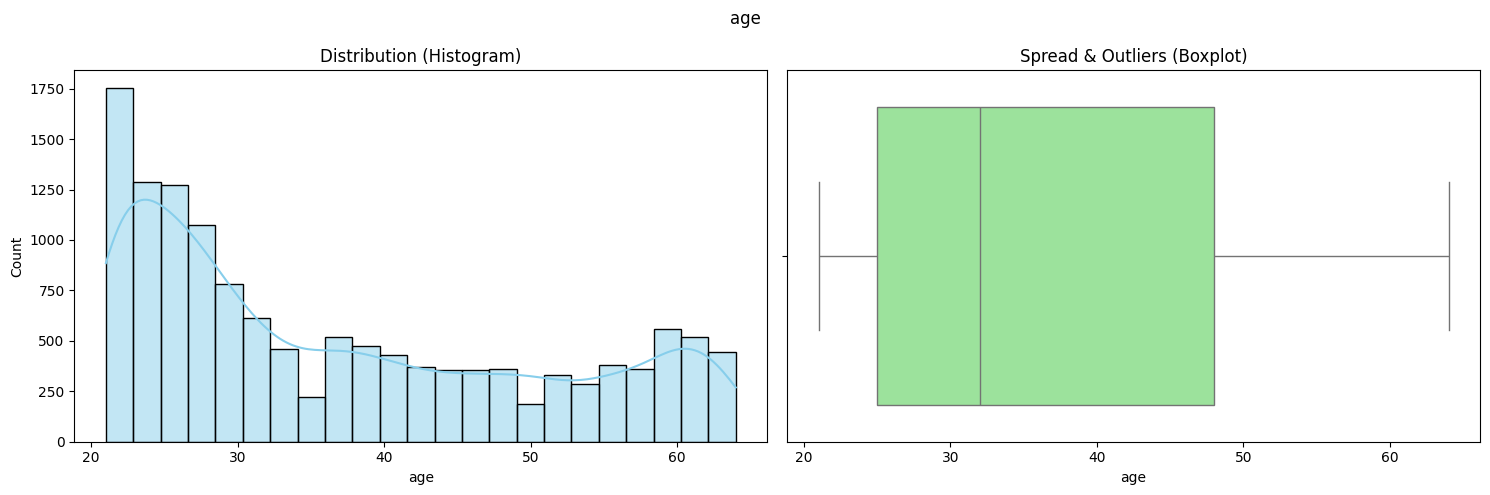

INSIGHTS & ACTIONS:
   No statistical outliers via IQR.
Univariate Analysis: height_cm
Mean: 168.5607 | Median: 169.2000 | Std: 8.4263
Skewness: -0.1870 (Target: 0)


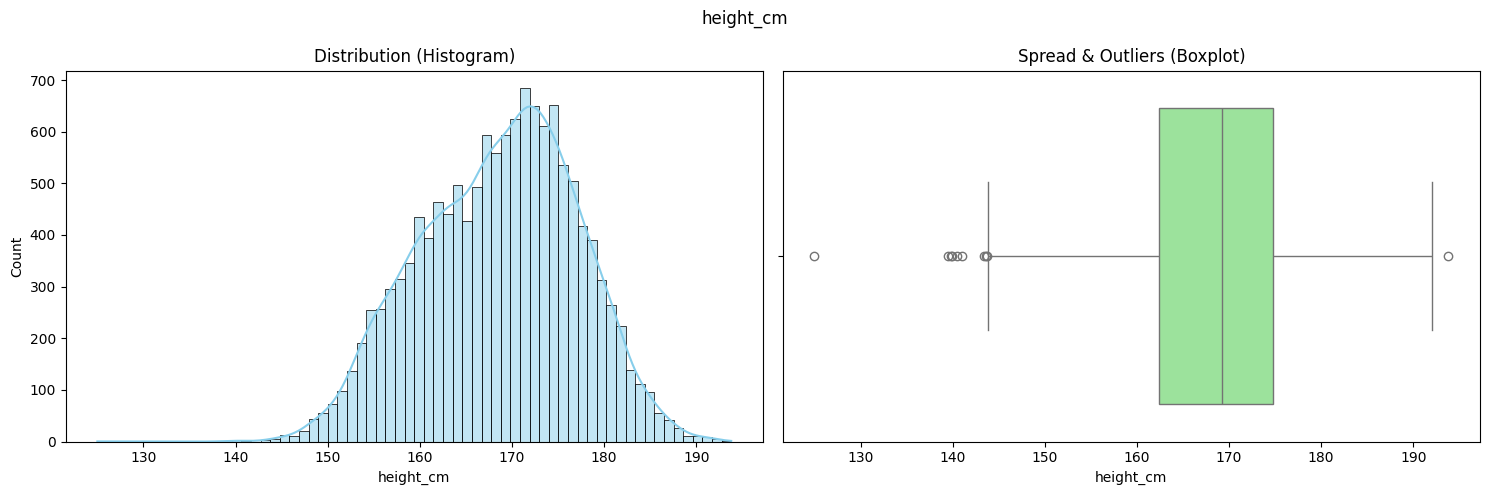

INSIGHTS & ACTIONS:
   Found 10 Outliers (< 143.80 or > 193.40).
Univariate Analysis: weight_kg
Mean: 67.4487 | Median: 67.4000 | Std: 11.9491
Skewness: 0.3498 (Target: 0)


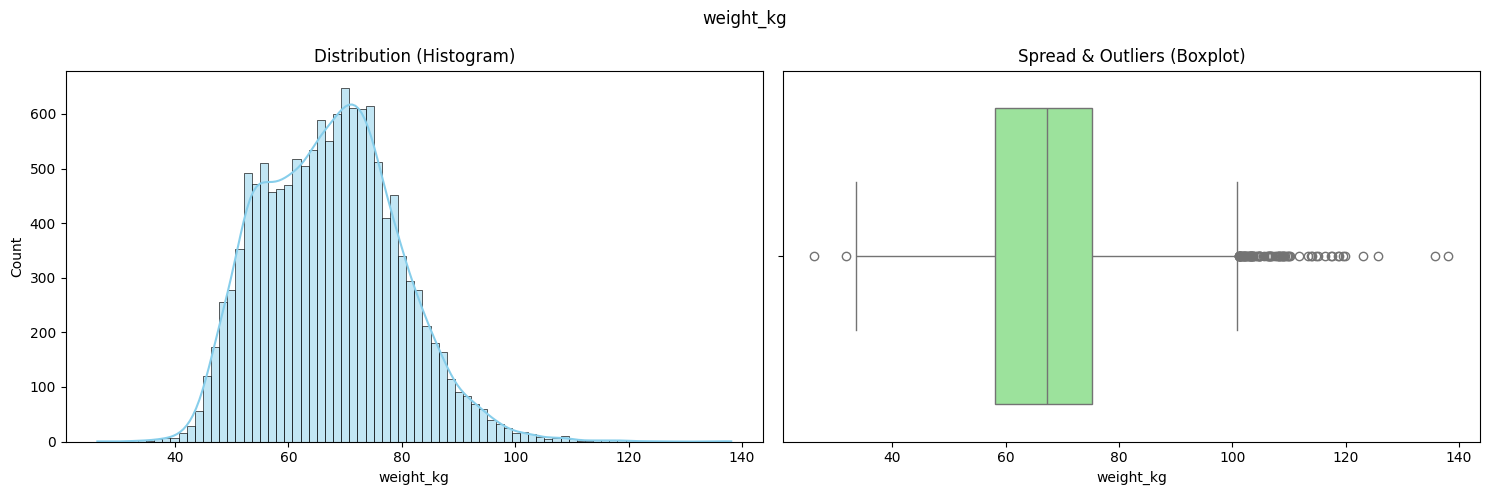

INSIGHTS & ACTIONS:
   Found 83 Outliers (< 32.55 or > 100.95).
Univariate Analysis: body fat_%
Mean: 23.2396 | Median: 22.8000 | Std: 7.2568
Skewness: 0.3613 (Target: 0)


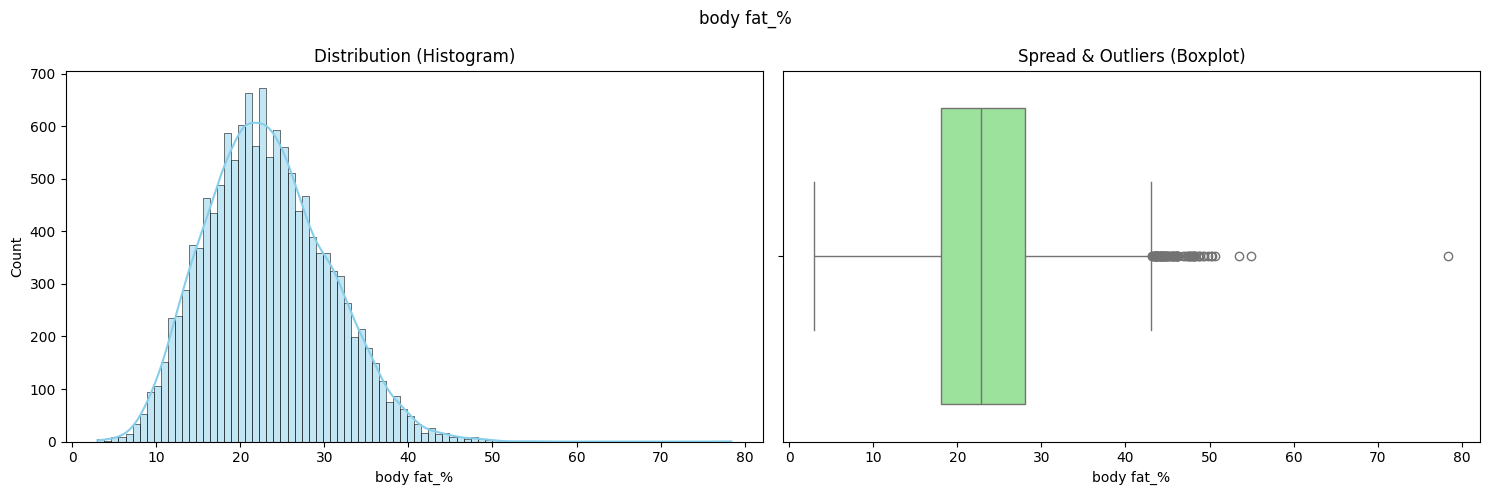

INSIGHTS & ACTIONS:
   Found 77 Outliers (< 3.00 or > 43.00).
Univariate Analysis: diastolic
Mean: 78.7975 | Median: 79.0000 | Std: 10.7422
Skewness: -0.1598 (Target: 0)


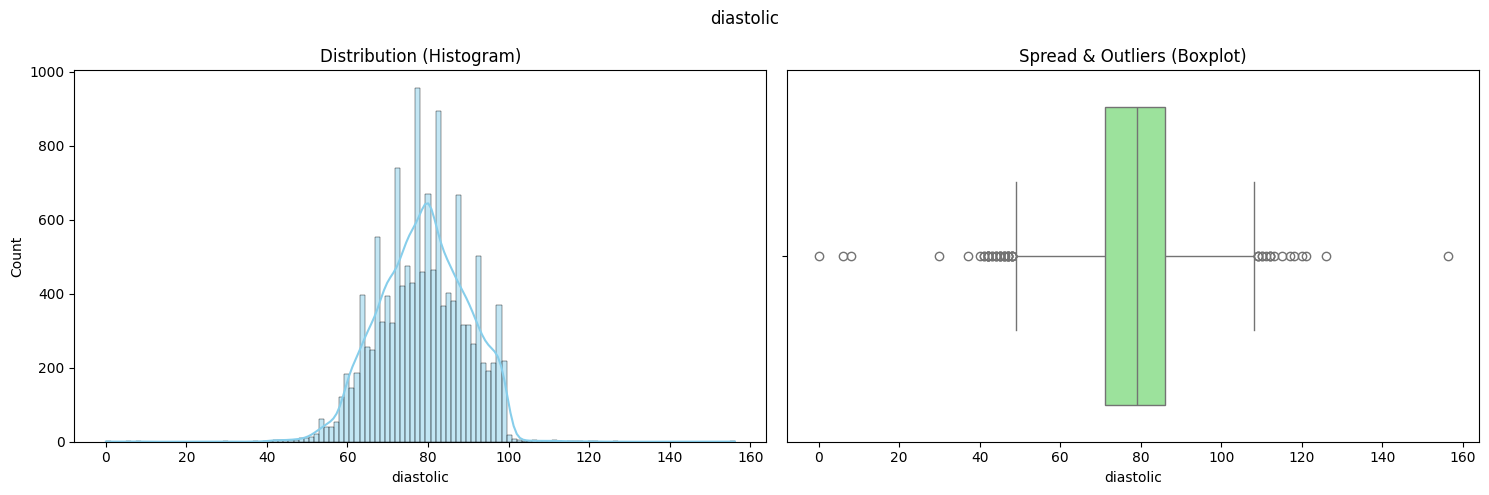

INSIGHTS & ACTIONS:
   Found 54 Outliers (< 48.50 or > 108.50).
Univariate Analysis: systolic
Mean: 130.2381 | Median: 130.0000 | Std: 14.7095
Skewness: -0.0473 (Target: 0)


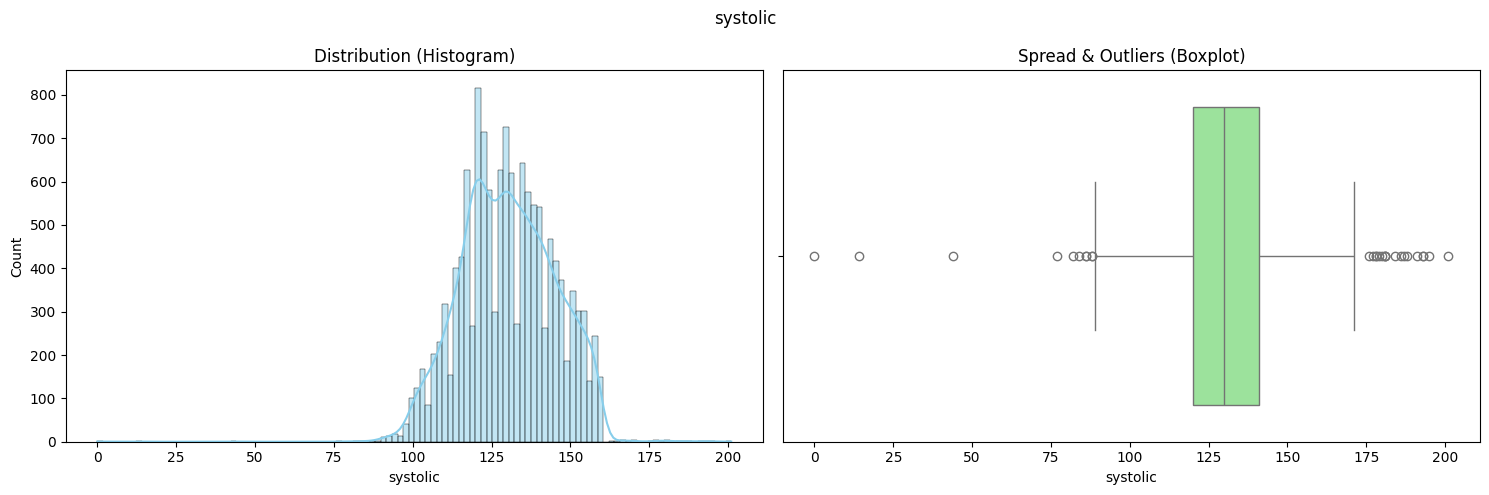

INSIGHTS & ACTIONS:
   Found 28 Outliers (< 88.50 or > 172.50).
Univariate Analysis: gripForce
Mean: 36.9646 | Median: 37.9000 | Std: 10.6250
Skewness: 0.0183 (Target: 0)


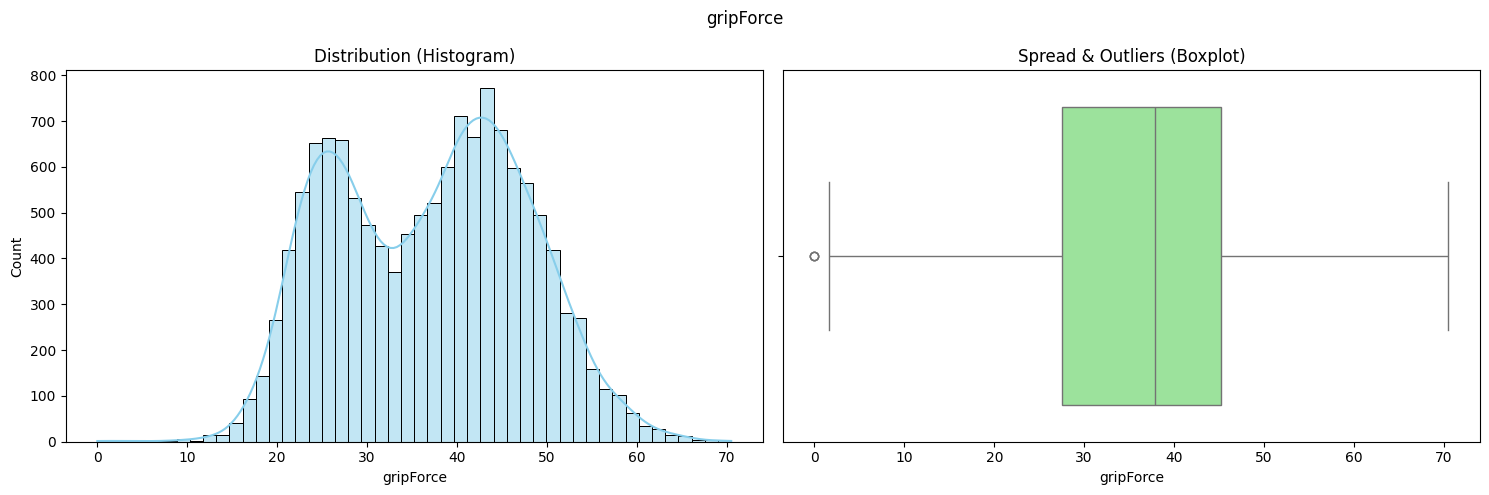

INSIGHTS & ACTIONS:
   Found 3 Outliers (< 0.95 or > 71.75).
Univariate Analysis: sit and bend forward_cm
Mean: 15.2089 | Median: 16.2000 | Std: 8.4569
Skewness: 0.7856 (Target: 0)


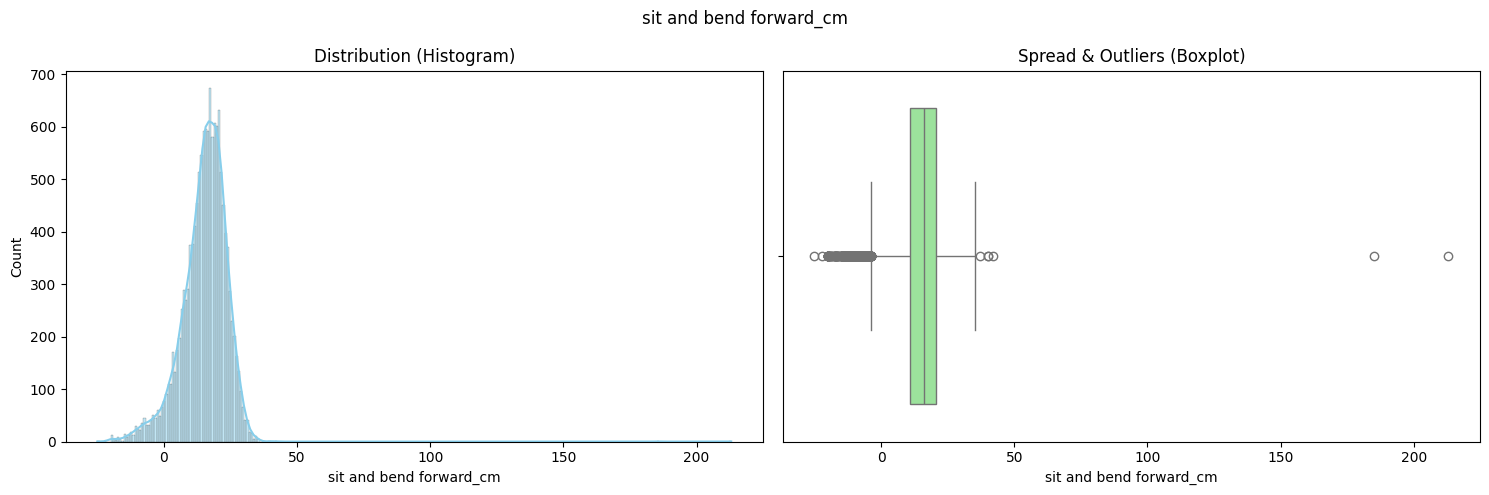

INSIGHTS & ACTIONS:
   Found 409 Outliers (< -3.80 or > 35.40).
Univariate Analysis: sit-ups counts
Mean: 39.7704 | Median: 41.0000 | Std: 14.2769
Skewness: -0.4677 (Target: 0)


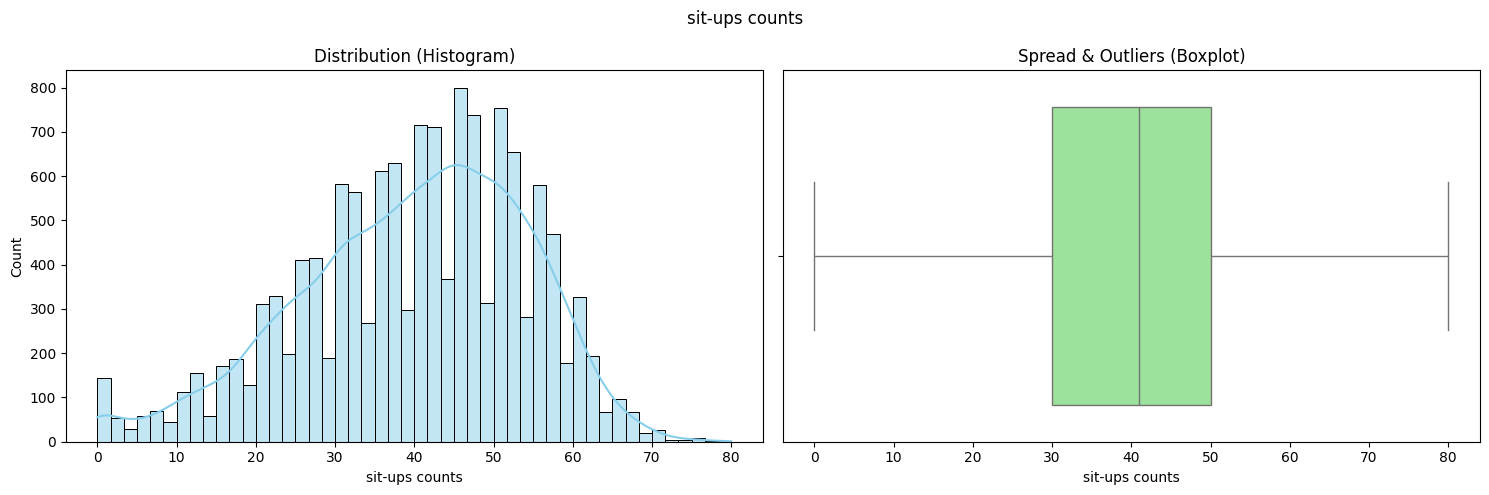

INSIGHTS & ACTIONS:
   No statistical outliers via IQR.
Univariate Analysis: broad jump_cm
Mean: 190.1314 | Median: 193.0000 | Std: 39.8690
Skewness: -0.4227 (Target: 0)


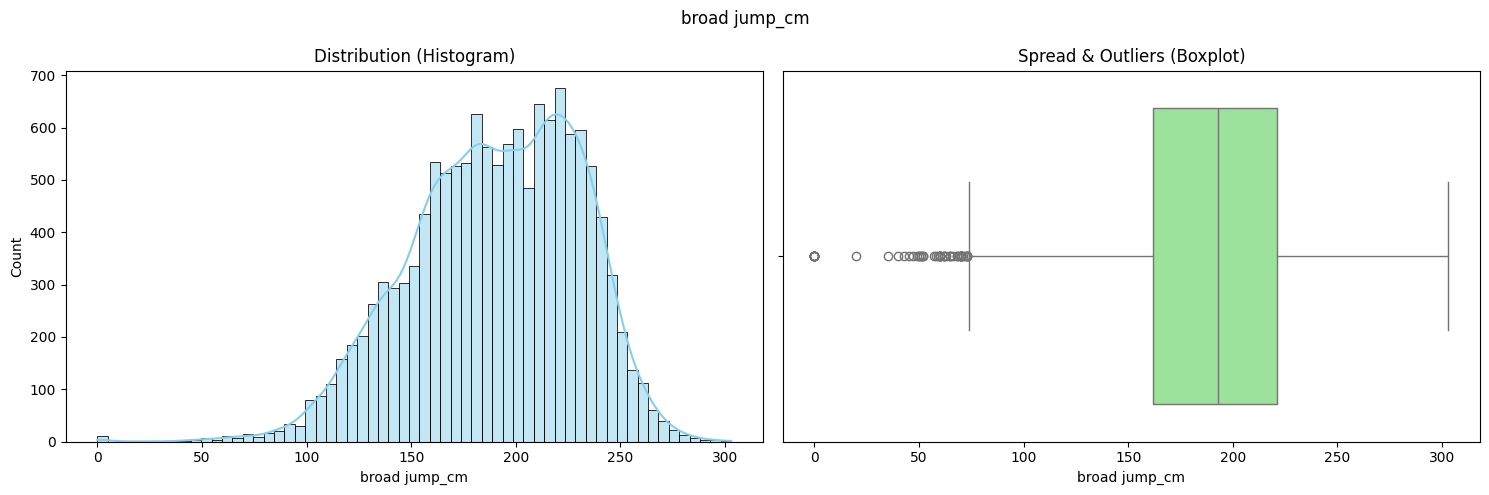

INSIGHTS & ACTIONS:
   Found 57 Outliers (< 73.50 or > 309.50).


In [ ]:
def analyze_numerical_variable(df, column):
    print(f'Univariate Analysis: {column}')
    desc = df[column].describe()
    skew = df[column].skew()
    print(f"Mean: {desc['mean']:.4f} | Median: {desc['50%']:.4f} | Std: {desc['std']:.4f}")
    print(f'Skewness: {skew:.4f} (Target: 0)')

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    sns.histplot(df[column].dropna(), kde=True, ax=axes[0], color='skyblue')
    axes[0].set_title('Distribution (Histogram)')
    sns.boxplot(x=df[column], ax=axes[1], color='lightgreen')
    axes[1].set_title('Spread & Outliers (Boxplot)')
    plt.suptitle(column)
    plt.tight_layout()
    plt.show()

    print('INSIGHTS & ACTIONS:')
    if abs(skew) > 1:
        print(f'   High Skewness ({skew:.2f}). -> Consider Log Transformation.')

    Q1 = desc['25%']; Q3 = desc['75%']; IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR; upper = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower) | (df[column] > upper)]
    if len(outliers) > 0:
        print(f'   Found {len(outliers)} Outliers (< {lower:.2f} or > {upper:.2f}).')
    else:
        print('   No statistical outliers via IQR.')

num_cols = df2.select_dtypes(include=[np.number]).columns.tolist()
for col in num_cols:
    analyze_numerical_variable(df2, col)

## Cell 7 — Data Cleaning & Feature Engineering

In [ ]:
from sklearn.preprocessing import LabelEncoder

# 1. Remove impossible blood pressure values
df = df[(df['systolic'] > 40) & (df['diastolic'] > 40)]

# 2. Cap flexibility outliers
df['sit and bend forward_cm'] = df['sit and bend forward_cm'].clip(lower=-20, upper=50)

# 3. Feature Engineering: BMI
df['BMI'] = df['weight_kg'] / ((df['height_cm'] / 100) ** 2)

# 4. Encode categorical variables
df['gender'] = df['gender'].map({'M': 0, 'F': 1})

le = LabelEncoder()
df['class'] = le.fit_transform(df['class'])

print(f'Cleaning complete! Remaining rows: {len(df)}')
print(df[['systolic', 'diastolic', 'sit and bend forward_cm']].describe())

Cleaning complete! Remaining rows: 13386
           systolic     diastolic  sit and bend forward_cm
count  13386.000000  13386.000000             13386.000000
mean     130.259219     78.824003                15.188535
std       14.630475     10.667022                 8.159867
min       43.900000     41.000000               -20.000000
25%      120.000000     71.000000                10.900000
50%      130.000000     79.000000                16.200000
75%      141.000000     86.000000                20.700000
max      201.000000    156.200000                50.000000


## Cell 8 — Univariate Analysis: Categorical


--- Univariate Analysis: gender ---


,Count,Percentage
gender,,
M,8467,63.224313
F,4925,36.775687


/tmp/ipykernel_534/586568756.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[column], order=counts.index, palette='viridis')


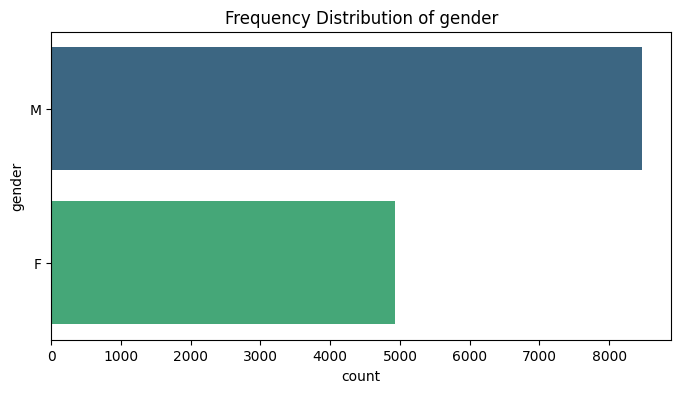


--- Univariate Analysis: class ---


,Count,Percentage
class,,
C,3349,25.007467
D,3349,25.007467
A,3347,24.992533
B,3347,24.992533


/tmp/ipykernel_534/586568756.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[column], order=counts.index, palette='viridis')


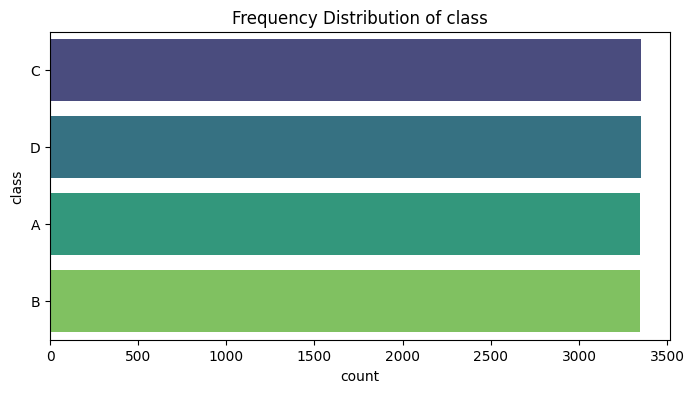

In [ ]:
def analyze_categorical_variable(df, column):
    print(f'\n--- Univariate Analysis: {column} ---')
    counts = df[column].value_counts()
    props = df[column].value_counts(normalize=True) * 100
    summary = pd.DataFrame({'Count': counts, 'Percentage': props})
    display(summary)
    plt.figure(figsize=(8, 4))
    sns.countplot(y=df[column], order=counts.index, palette='viridis')
    plt.title(f'Frequency Distribution of {column}')
    plt.show()

cat_cols = df2.select_dtypes(include=['object', 'category']).columns.tolist()
for col in cat_cols:
    if df2[col].nunique() < 30:
        analyze_categorical_variable(df2, col)

## Cell 9 — Multivariate Analysis: Correlation Matrix

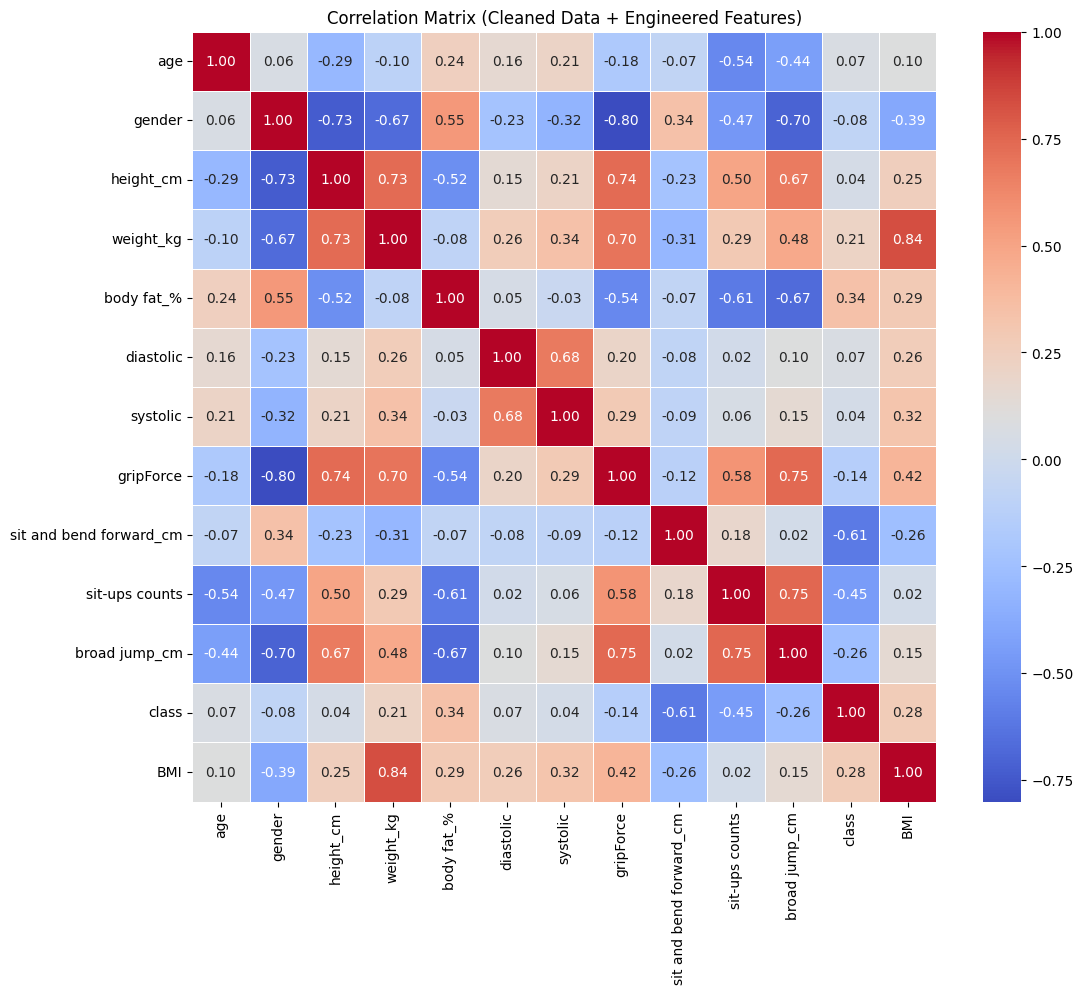

Data processing complete.
Remaining records: 13386
Class mapping: ['A', 'B', 'C', 'D'] -> [0, 1, 2, 3]


In [ ]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df[num_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix (Cleaned Data + Engineered Features)')
plt.show()

print('Data processing complete.')
print(f'Remaining records: {len(df)}')
print(f"Class mapping: {list(le.classes_)} -> [0, 1, 2, 3]")

## Cell 10 — Neural Network Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Activation
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

## Cell 11 — Feature & Target Preparation

**Important fix:** The scaler is NOT fitted here on all data.
It is fitted separately inside each split on the training portion only.
This prevents data leakage from test set statistics influencing the model.

In [ ]:
X = df.drop(columns=['class']).values   # raw, unscaled
y = df['class'].values                  # integer labels

print(f'Feature matrix X : {X.shape}')
print(f'Target vector  y : {y.shape}')
print(f'Classes          : {np.unique(y)} -> {list(le.classes_)}')

Feature matrix X : (13386, 12)
Target vector  y : (13386,)
Classes          : [0 1 2 3] -> ['A', 'B', 'C', 'D']


In [ ]:
def build_model(input_dim=12):
    """
    Upgraded neural network architecture.
    Pattern per hidden block: Dense → BatchNormalization → ELU → Dropout
    BatchNorm goes BEFORE the activation so it normalises raw pre-activations.
    """
    model = Sequential([

        # ── Block 1 ───────────────────────────────────────────
        Dense(256, input_dim=input_dim, use_bias=False),
        BatchNormalization(),
        Activation('elu'),
        Dropout(0.2),

        # ── Block 2 ───────────────────────────────────────────
        Dense(128, use_bias=False),
        BatchNormalization(),
        Activation('elu'),
        Dropout(0.2),

        # ── Block 3 ───────────────────────────────────────────
        Dense(64, use_bias=False),
        BatchNormalization(),
        Activation('elu'),
        Dropout(0.2),

        # ── Block 4 (no Dropout before output) ────────────────
        Dense(32, use_bias=False),
        BatchNormalization(),
        Activation('elu'),

        # ── Output ────────────────────────────────────────────
        Dense(4, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# Preview architecture
build_model().summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         3,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 48,132 (188.02 KB)

 Trainable params: 47,172 (184.27 KB)

 Non-trainable params: 960 (3.75 KB)

---
## Cell 12 — Experiment 1: 80:20 Split

The standard split. 80% training gives the model plenty of data.
Scaler is fitted ONLY on X_train — never on X_test.

In [ ]:
# ── Split ────────────────────────────────────────────────────────
X_train_80, X_test_80, y_train_80, y_test_80 = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y  # stratify keeps class balance
)

# ── Scale (fit on train only — prevents data leakage) ────────────
scaler_80 = StandardScaler()
X_train_80 = scaler_80.fit_transform(X_train_80)   # learns mean & std from train
X_test_80  = scaler_80.transform(X_test_80)         # applies same stats to test

# ── One-hot encode labels ────────────────────────────────────────
y_train_80_cat = to_categorical(y_train_80, num_classes=4)
y_test_80_cat  = to_categorical(y_test_80,  num_classes=4)

print(f'Train : {X_train_80.shape[0]} samples')
print(f'Test  : {X_test_80.shape[0]}  samples')

Train : 10708 samples
Test  : 2678  samples


In [ ]:
# ── Callbacks ────────────────────────────────────────────────────
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

# ReduceLROnPlateau: halves the learning rate when val_loss stops improving.
# This lets the model "zoom in" near the minimum and squeeze out extra accuracy.
lr_decay = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

# ── Build & Train ─────────────────────────────────────────────────
model_80 = build_model(input_dim=X_train_80.shape[1])

history_80 = model_80.fit(
    X_train_80, y_train_80_cat,
    validation_split=0.15,
    epochs=200,
    batch_size=32,
    callbacks=[early_stop, lr_decay],
    verbose=1
)

Epoch 1/200


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


285/285 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.5464 - loss: 0.9956 - val_accuracy: 0.6416 - val_loss: 0.8237 - learning_rate: 0.0010
Epoch 2/200
285/285 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6042 - loss: 0.8931 - val_accuracy: 0.6683 - val_loss: 0.7777 - learning_rate: 0.0010
Epoch 3/200
285/285 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6234 - loss: 0.8543 - val_accuracy: 0.6907 - val_loss: 0.7401 - learning_rate: 0.0010
Epoch 4/200
285/285 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6354 - loss: 0.8340 - val_accuracy: 0.7026 - val_loss: 0.7215 - learning_rate: 0.0010
Epoch 5/200
285/285 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6401 - loss: 0.8284 - val_accuracy: 0.7106 - val_loss: 0.7084 - learning_rate: 0.0010
Epoch 6/200
285/285 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6452 - loss: 0.8152 - val_accuracy: 0.7082 - val_loss: 0.7039 - learning_rate: 0.0010
Epoch 7/200
285/285 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6500 - loss: 0.8057 - val_a

In [ ]:
# ── Evaluate ─────────────────────────────────────────────────────
y_pred_80   = np.argmax(model_80.predict(X_test_80), axis=1)
accuracy_80 = accuracy_score(y_test_80, y_pred_80)

print(f'\n=========================================')
print(f'  80:20 Split  —  Test Accuracy: {accuracy_80*100:.2f}%')
print(f'=========================================')
print(classification_report(y_test_80, y_pred_80, target_names=le.classes_))

84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

  80:20 Split  —  Test Accuracy: 74.76%
              precision    recall  f1-score   support

           A       0.74      0.89      0.81       670
           B       0.62      0.61      0.61       669
           C       0.73      0.68      0.70       670
           D       0.92      0.82      0.87       669

    accuracy                           0.75      2678
   macro avg       0.75      0.75      0.75      2678
weighted avg       0.75      0.75      0.75      2678



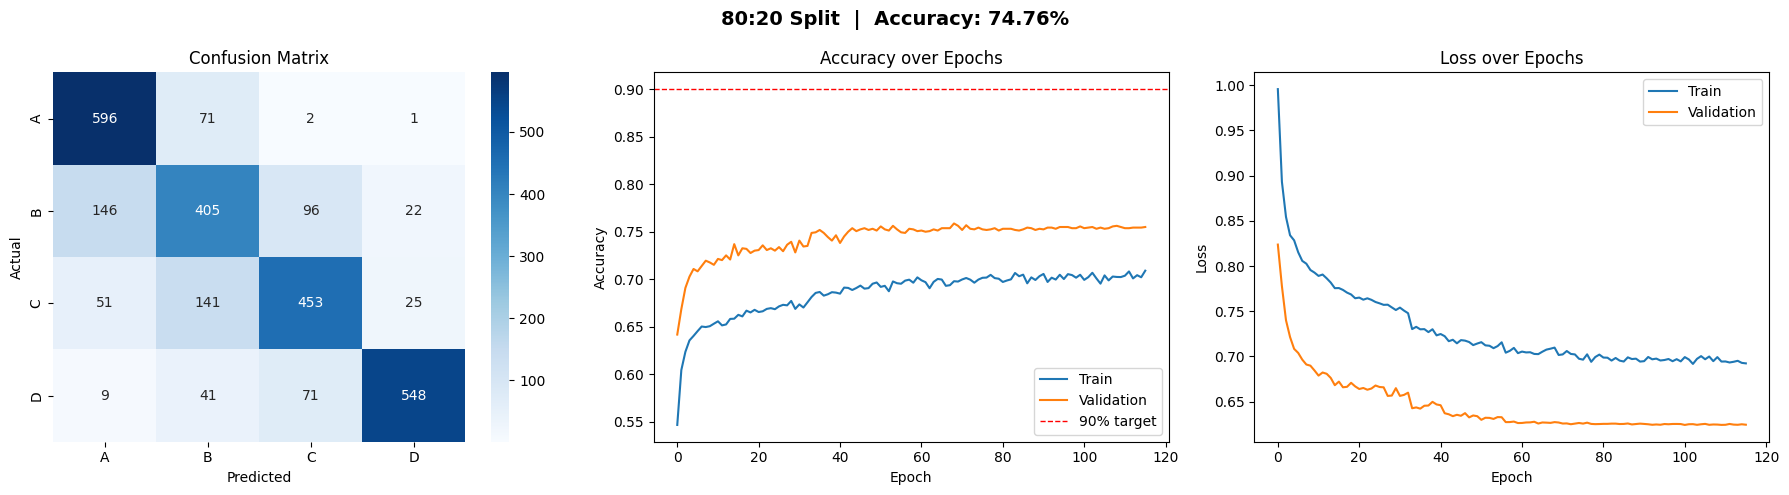

In [ ]:
# ── Plots ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'80:20 Split  |  Accuracy: {accuracy_80*100:.2f}%', fontsize=14, fontweight='bold')

# Confusion matrix
cm_80 = confusion_matrix(y_test_80, y_pred_80)
sns.heatmap(cm_80, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[0])
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

# Accuracy curve
axes[1].plot(history_80.history['accuracy'],     label='Train')
axes[1].plot(history_80.history['val_accuracy'], label='Validation')
axes[1].axhline(0.90, color='red', linestyle='--', linewidth=1, label='90% target')
axes[1].set_title('Accuracy over Epochs')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend()

# Loss curve
axes[2].plot(history_80.history['loss'],     label='Train')
axes[2].plot(history_80.history['val_loss'], label='Validation')
axes[2].set_title('Loss over Epochs')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Loss')
axes[2].legend()

plt.tight_layout()
plt.show()

---
## Cell 13 — Experiment 2: 70:30 Split

Larger test set gives a more conservative generalisation estimate.
A fresh `StandardScaler` is created so train/test statistics are independent.

In [ ]:
X_train_70, X_test_70, y_train_70, y_test_70 = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y
)

scaler_70 = StandardScaler()
X_train_70 = scaler_70.fit_transform(X_train_70)
X_test_70  = scaler_70.transform(X_test_70)

y_train_70_cat = to_categorical(y_train_70, num_classes=4)
y_test_70_cat  = to_categorical(y_test_70,  num_classes=4)

print(f'Train : {X_train_70.shape[0]} samples')
print(f'Test  : {X_test_70.shape[0]}  samples')

Train : 9370 samples
Test  : 4016  samples


In [ ]:
model_70 = build_model(input_dim=X_train_70.shape[1])

early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1)
lr_decay   = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)

history_70 = model_70.fit(
    X_train_70, y_train_70_cat,
    validation_split=0.15,
    epochs=200,
    batch_size=32,
    callbacks=[early_stop, lr_decay],
    verbose=1
)

y_pred_70   = np.argmax(model_70.predict(X_test_70), axis=1)
accuracy_70 = accuracy_score(y_test_70, y_pred_70)

print(f'\n=========================================')
print(f'  70:30 Split  —  Test Accuracy: {accuracy_70*100:.2f}%')
print(f'=========================================')
print(classification_report(y_test_70, y_pred_70, target_names=le.classes_))

Epoch 1/200


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


249/249 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.5481 - loss: 0.9976 - val_accuracy: 0.6088 - val_loss: 0.8718 - learning_rate: 0.0010
Epoch 2/200
249/249 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6033 - loss: 0.8837 - val_accuracy: 0.6408 - val_loss: 0.8180 - learning_rate: 0.0010
Epoch 3/200
249/249 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6202 - loss: 0.8553 - val_accuracy: 0.6558 - val_loss: 0.7800 - learning_rate: 0.0010
Epoch 4/200
249/249 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6269 - loss: 0.8381 - val_accuracy: 0.6607 - val_loss: 0.7755 - learning_rate: 0.0010
Epoch 5/200
249/249 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6425 - loss: 0.8157 - val_accuracy: 0.6785 - val_loss: 0.7518 - learning_rate: 0.0010
Epoch 6/200
249/249 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6416 - loss: 0.8125 - val_accuracy: 0.6792 - val_loss: 0.7476 - learning_rate: 0.0010
Epoch 7/200
249/249 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6546 - loss: 0.8058 - val_a

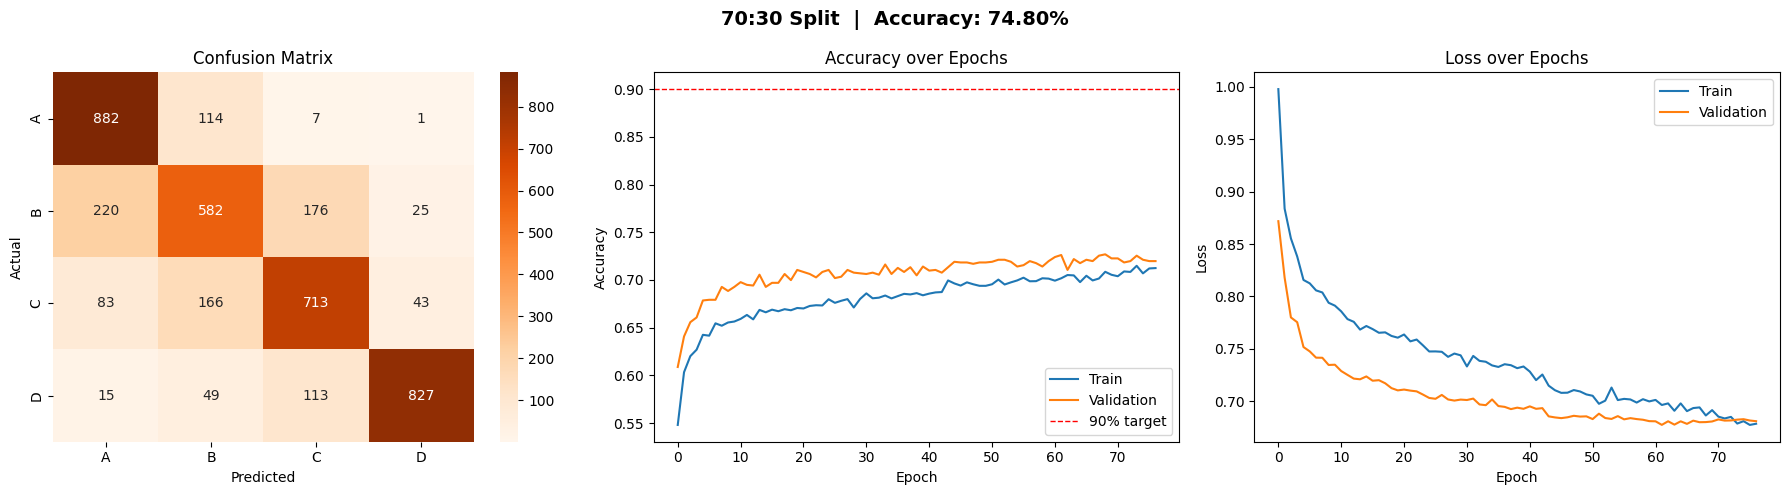

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'70:30 Split  |  Accuracy: {accuracy_70*100:.2f}%', fontsize=14, fontweight='bold')

cm_70 = confusion_matrix(y_test_70, y_pred_70)
sns.heatmap(cm_70, annot=True, fmt='d', cmap='Oranges',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[0])
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

axes[1].plot(history_70.history['accuracy'],     label='Train')
axes[1].plot(history_70.history['val_accuracy'], label='Validation')
axes[1].axhline(0.90, color='red', linestyle='--', linewidth=1, label='90% target')
axes[1].set_title('Accuracy over Epochs')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy'); axes[1].legend()

axes[2].plot(history_70.history['loss'],     label='Train')
axes[2].plot(history_70.history['val_loss'], label='Validation')
axes[2].set_title('Loss over Epochs')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Loss'); axes[2].legend()

plt.tight_layout()
plt.show()

---
## Cell 14 — Experiment 3: 50:50 Split

Equal split — the model sees only half the data for training.
This is a stress test for generalisation.

In [ ]:
X_train_50, X_test_50, y_train_50, y_test_50 = train_test_split(
    X, y, test_size=0.50, random_state=SEED, stratify=y
)

scaler_50 = StandardScaler()
X_train_50 = scaler_50.fit_transform(X_train_50)
X_test_50  = scaler_50.transform(X_test_50)

y_train_50_cat = to_categorical(y_train_50, num_classes=4)
y_test_50_cat  = to_categorical(y_test_50,  num_classes=4)

print(f'Train : {X_train_50.shape[0]} samples')
print(f'Test  : {X_test_50.shape[0]}  samples')

Train : 6693 samples
Test  : 6693  samples


In [ ]:
model_50 = build_model(input_dim=X_train_50.shape[1])

early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1)
lr_decay   = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)

history_50 = model_50.fit(
    X_train_50, y_train_50_cat,
    validation_split=0.15,
    epochs=200,
    batch_size=32,
    callbacks=[early_stop, lr_decay],
    verbose=1
)

y_pred_50   = np.argmax(model_50.predict(X_test_50), axis=1)
accuracy_50 = accuracy_score(y_test_50, y_pred_50)

print(f'\n=========================================')
print(f'  50:50 Split  —  Test Accuracy: {accuracy_50*100:.2f}%')
print(f'=========================================')
print(classification_report(y_test_50, y_pred_50, target_names=le.classes_))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/200
178/178 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.5307 - loss: 1.0613 - val_accuracy: 0.6096 - val_loss: 0.9002 - learning_rate: 0.0010
Epoch 2/200
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5801 - loss: 0.9149 - val_accuracy: 0.6165 - val_loss: 0.8560 - learning_rate: 0.0010
Epoch 3/200
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6092 - loss: 0.8751 - val_accuracy: 0.6225 - val_loss: 0.8135 - learning_rate: 0.0010
Epoch 4/200
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6228 - loss: 0.8528 - val_accuracy: 0.6484 - val_loss: 0.7714 - learning_rate: 0.0010
Epoch 5/200
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6324 - loss: 0.8303 - val_accuracy: 0.6733 - val_loss: 0.7519 - learning_rate: 0.0010
Epoch 6/200
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6453 - loss: 0.8278 - val_accuracy: 0.6624 - val_loss: 0.7588 - learning_rate: 0.0010
Epoch 7/200
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6446 - loss: 0.

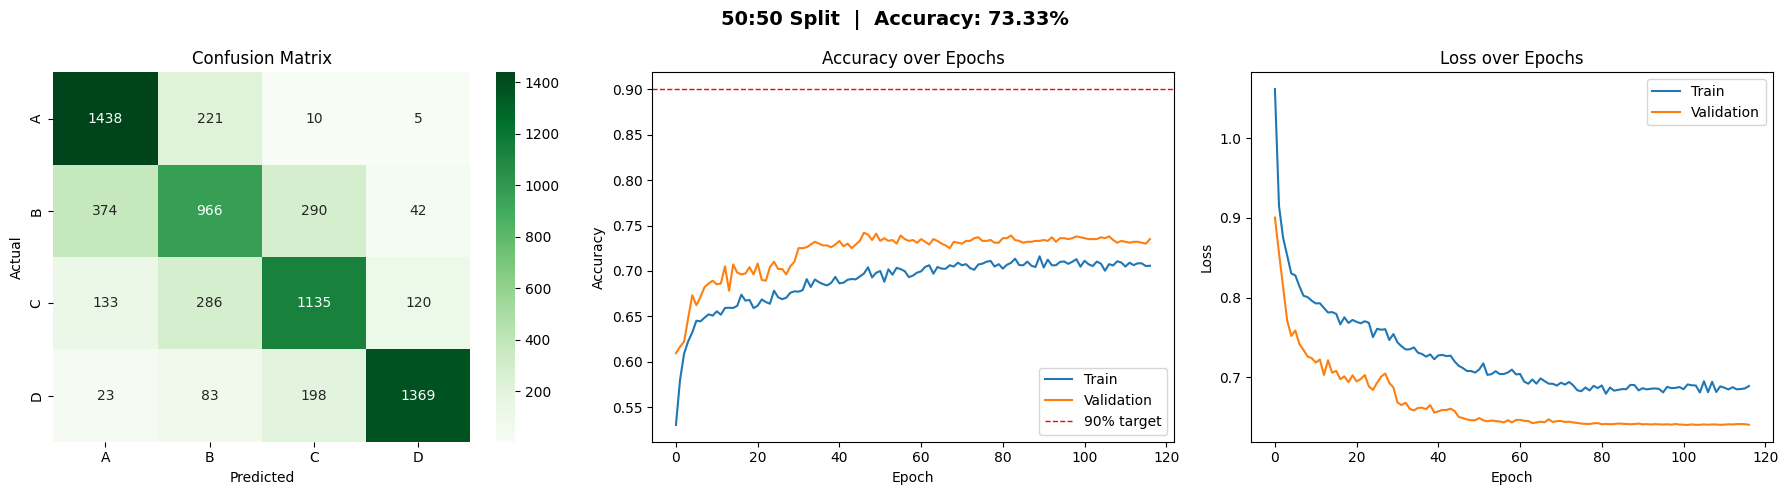

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'50:50 Split  |  Accuracy: {accuracy_50*100:.2f}%', fontsize=14, fontweight='bold')

cm_50 = confusion_matrix(y_test_50, y_pred_50)
sns.heatmap(cm_50, annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[0])
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

axes[1].plot(history_50.history['accuracy'],     label='Train')
axes[1].plot(history_50.history['val_accuracy'], label='Validation')
axes[1].axhline(0.90, color='red', linestyle='--', linewidth=1, label='90% target')
axes[1].set_title('Accuracy over Epochs')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy'); axes[1].legend()

axes[2].plot(history_50.history['loss'],     label='Train')
axes[2].plot(history_50.history['val_loss'], label='Validation')
axes[2].set_title('Loss over Epochs')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Loss'); axes[2].legend()

plt.tight_layout()
plt.show()

---
## Cell 15 — Split Comparison Summary


        TRAIN/TEST SPLIT COMPARISON RESULTS
 Experiment  Train Samples  Test Samples  Test Accuracy (%) Exceeds 90%
80:20 Split          10708          2678              74.76          No
70:30 Split           9370          4016              74.80          No
50:50 Split           6693          6693              73.33          No


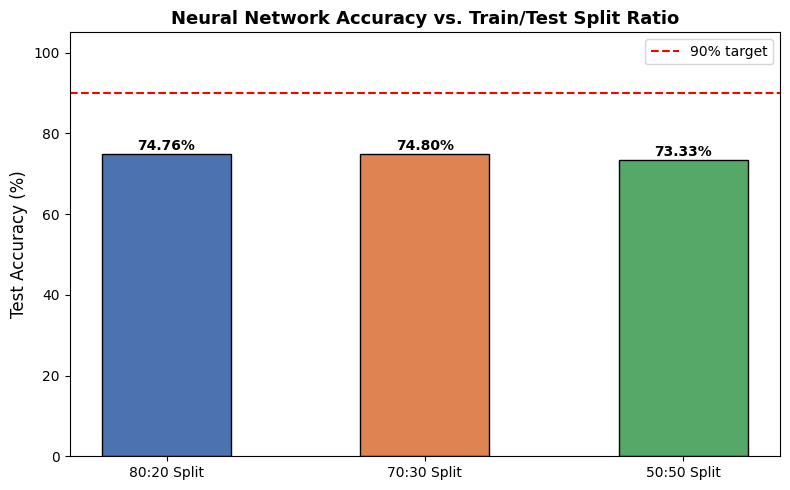

In [ ]:
split_results = pd.DataFrame({
    'Experiment'        : ['80:20 Split', '70:30 Split', '50:50 Split'],
    'Train Samples'     : [X_train_80.shape[0], X_train_70.shape[0], X_train_50.shape[0]],
    'Test Samples'      : [X_test_80.shape[0],  X_test_70.shape[0],  X_test_50.shape[0]],
    'Test Accuracy (%)'  : [round(accuracy_80*100, 2), round(accuracy_70*100, 2), round(accuracy_50*100, 2)],
    'Exceeds 90%'       : ['Yes' if accuracy_80>=0.90 else 'No',
                           'Yes' if accuracy_70>=0.90 else 'No',
                           'Yes' if accuracy_50>=0.90 else 'No']
})

print('\n' + '='*60)
print('        TRAIN/TEST SPLIT COMPARISON RESULTS')
print('='*60)
print(split_results.to_string(index=False))
print('='*60)

# Bar chart
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#4C72B0', '#DD8452', '#55A868']
bars = ax.bar(split_results['Experiment'],
              split_results['Test Accuracy (%)'],
              color=colors, edgecolor='black', width=0.5)
for bar, val in zip(bars, split_results['Test Accuracy (%)']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.2f}%', ha='center', va='bottom', fontweight='bold')
ax.set_ylim(0, 105)
ax.set_ylabel('Test Accuracy (%)', fontsize=12)
ax.set_title('Neural Network Accuracy vs. Train/Test Split Ratio', fontsize=13, fontweight='bold')
ax.axhline(y=90, color='red', linestyle='--', linewidth=1.5, label='90% target')
ax.legend()
plt.tight_layout()
plt.show()

---
## Cell 16 — K-Fold Cross-Validation

### Theory

A single train/test split can be lucky or unlucky depending on which samples land in each set.
**K-Fold Cross-Validation** removes this bias:

1. Divides data into **k equal folds**
2. Trains on k−1 folds, evaluates on the remaining fold
3. Repeats k times so every sample is in the test set exactly once
4. Reports **mean ± standard deviation** of accuracy

We use **Stratified K-Fold** to preserve class proportions in each fold.

| k | Each fold size | Bias | Variance |
|---|---------------|------|----------|
| 5 | 20% of data   | Slightly higher | Lower |
| 10 | 10% of data  | Lower | Slightly higher |

In [ ]:
def run_kfold_cv(X, y, n_splits=5, epochs=150, batch_size=32, patience=15):
    """
    Stratified K-Fold cross-validation for the upgraded neural network.
    Each fold gets its own StandardScaler fitted only on that fold's training data.
    """
    skf             = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    fold_accuracies = []

    print(f'\n{"="*55}')
    print(f'  {n_splits}-FOLD STRATIFIED CROSS-VALIDATION')
    print(f'{"="*55}')

    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), start=1):

        # ── Split ──────────────────────────────────────────────
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]

        # ── Scale (fit on training fold only) ──────────────────
        scaler = StandardScaler()
        X_tr = scaler.fit_transform(X_tr)
        X_te = scaler.transform(X_te)

        # ── One-hot encode ─────────────────────────────────────
        y_tr_cat = to_categorical(y_tr, num_classes=4)

        # ── Build fresh model ──────────────────────────────────
        fold_model = build_model(input_dim=X_tr.shape[1])
        es = EarlyStopping(monitor='val_loss', patience=patience, restore_best_weights=True)
        lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)

        fold_model.fit(
            X_tr, y_tr_cat,
            validation_split=0.15,
            epochs=epochs,
            batch_size=batch_size,
            callbacks=[es, lr],
            verbose=0   # silent per fold
        )

        # ── Evaluate ───────────────────────────────────────────
        y_pred_fold = np.argmax(fold_model.predict(X_te, verbose=0), axis=1)
        acc         = accuracy_score(y_te, y_pred_fold)
        fold_accuracies.append(acc)

        print(f'  Fold {fold}/{n_splits}  |  '
              f'Train: {len(train_idx):5d}  Test: {len(test_idx):4d}  |  '
              f'Accuracy: {acc*100:.2f}%')

    mean_acc = np.mean(fold_accuracies)
    std_acc  = np.std(fold_accuracies)

    print(f'{"─"*55}')
    print(f'  Mean Accuracy : {mean_acc*100:.2f}%')
    print(f'  Std Deviation : ±{std_acc*100:.2f}%')
    print(f'  95% CI        : [{(mean_acc-2*std_acc)*100:.2f}%,  {(mean_acc+2*std_acc)*100:.2f}%]')
    print(f'{"="*55}')

    return fold_accuracies

### 5-Fold Cross-Validation

In [ ]:
cv5_accuracies = run_kfold_cv(X, y, n_splits=5, epochs=150, patience=15)


  5-FOLD STRATIFIED CROSS-VALIDATION


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  Fold 1/5  |  Train: 10708  Test: 2678  |  Accuracy: 73.90%


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  Fold 2/5  |  Train: 10709  Test: 2677  |  Accuracy: 74.34%


...

  Fold 3/5  |  Train: 10709  Test: 2677  |  Accuracy: 73.37%


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  Fold 4/5  |  Train: 10709  Test: 2677  |  Accuracy: 74.67%


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  Fold 5/5  |  Train: 10709  Test: 2677  |  Accuracy: 73.63%
───────────────────────────────────────────────────────
  Mean Accuracy : 73.98%
  Std Deviation : ±0.47%
  95% CI        : [73.04%,  74.93%]


### 10-Fold Cross-Validation

In [ ]:
cv10_accuracies = run_kfold_cv(X, y, n_splits=10, epochs=150, patience=15)


  10-FOLD STRATIFIED CROSS-VALIDATION


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  Fold 1/10  |  Train: 12047  Test: 1339  |  Accuracy: 73.11%


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  Fold 2/10  |  Train: 12047  Test: 1339  |  Accuracy: 72.89%


...

  Fold 8/10  |  Train: 12048  Test: 1338  |  Accuracy: 74.59%


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  Fold 9/10  |  Train: 12048  Test: 1338  |  Accuracy: 74.36%


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  Fold 10/10  |  Train: 12048  Test: 1338  |  Accuracy: 73.24%
───────────────────────────────────────────────────────
  Mean Accuracy : 73.88%
  Std Deviation : ±0.82%
  95% CI        : [72.23%,  75.52%]


### K-Fold Results Visualisation

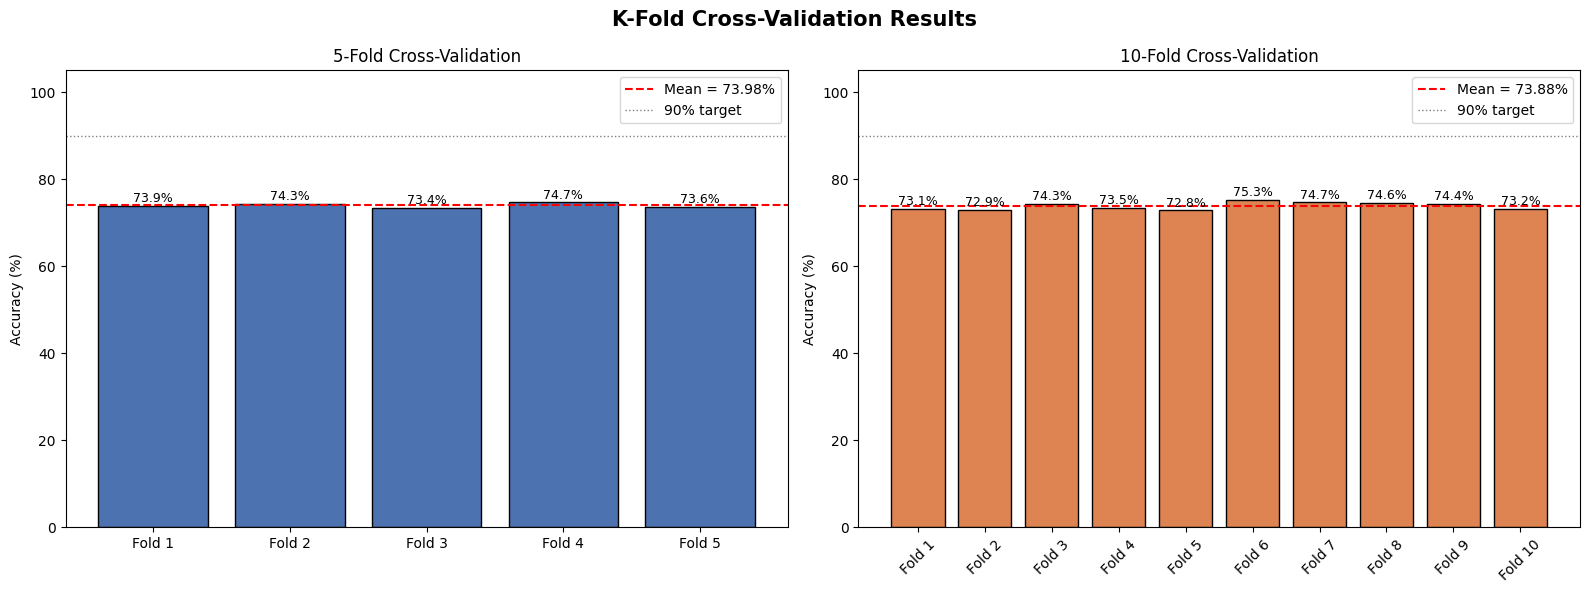

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('K-Fold Cross-Validation Results', fontsize=15, fontweight='bold')

for ax, accs, k, color in [
    (axes[0], cv5_accuracies,  5,  '#4C72B0'),
    (axes[1], cv10_accuracies, 10, '#DD8452')
]:
    folds = [f'Fold {i+1}' for i in range(len(accs))]
    bars  = ax.bar(folds, [a*100 for a in accs], color=color, edgecolor='black')
    ax.axhline(np.mean(accs)*100, color='red',  linestyle='--',
               label=f'Mean = {np.mean(accs)*100:.2f}%')
    ax.axhline(90, color='gray', linestyle=':', linewidth=1, label='90% target')
    for bar, val in zip(bars, accs):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                f'{val*100:.1f}%', ha='center', va='bottom', fontsize=9)
    ax.set_ylim(0, 105)
    ax.set_ylabel('Accuracy (%)')
    ax.set_title(f'{k}-Fold Cross-Validation')
    ax.legend()
    if k == 10:
        ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

---
## Cell 17— Final Comparison: All Experiments


         FINAL EXPERIMENT COMPARISON SUMMARY
       Experiment  Test Accuracy (%) Std Dev (±%) Exceeds 90%
      80:20 Split              74.76            -          No
      70:30 Split              74.80            -          No
      50:50 Split              73.33            -          No
 5-Fold CV (mean)              73.98         0.47          No
10-Fold CV (mean)              73.88         0.82          No


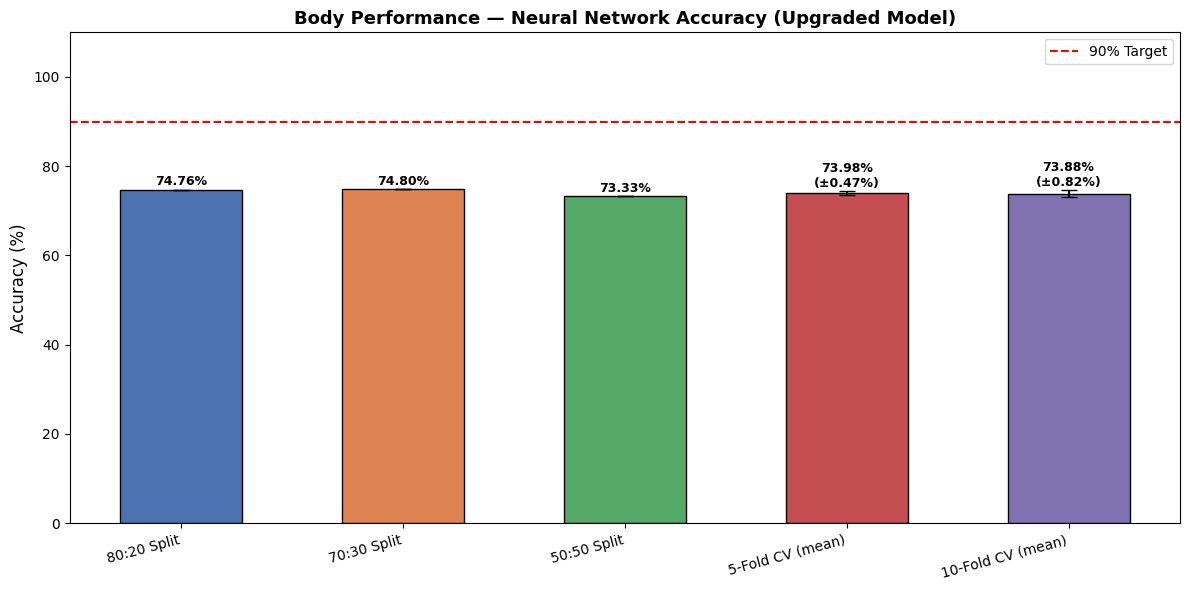

In [ ]:
all_results = pd.DataFrame({
    'Experiment'         : ['80:20 Split', '70:30 Split', '50:50 Split',
                             '5-Fold CV (mean)', '10-Fold CV (mean)'],
    'Test Accuracy (%)'  : [
        round(accuracy_80*100, 2),
        round(accuracy_70*100, 2),
        round(accuracy_50*100, 2),
        round(np.mean(cv5_accuracies)*100, 2),
        round(np.mean(cv10_accuracies)*100, 2)
    ],
    'Std Dev (±%)'       : [
        '-', '-', '-',
        round(np.std(cv5_accuracies)*100,  2),
        round(np.std(cv10_accuracies)*100, 2)
    ],
    'Exceeds 90%'        : [
        'Yes' if accuracy_80>=0.90 else 'No',
        'Yes' if accuracy_70>=0.90 else 'No',
        'Yes' if accuracy_50>=0.90 else 'No',
        'Yes' if np.mean(cv5_accuracies)>=0.90  else 'No',
        'Yes' if np.mean(cv10_accuracies)>=0.90 else 'No'
    ]
})

print('\n' + '='*65)
print('         FINAL EXPERIMENT COMPARISON SUMMARY')
print('='*65)
print(all_results.to_string(index=False))
print('='*65)

# Combined bar chart with error bars
labels   = all_results['Experiment'].tolist()
accs     = all_results['Test Accuracy (%)'].tolist()
std_devs = [0, 0, 0,
            round(np.std(cv5_accuracies)*100,  2),
            round(np.std(cv10_accuracies)*100, 2)]

fig, ax = plt.subplots(figsize=(12, 6))
colors_all = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']
x_pos = np.arange(len(labels))
bars = ax.bar(x_pos, accs, color=colors_all, edgecolor='black',
              yerr=std_devs, capsize=6, width=0.55)

for bar, val, std in zip(bars, accs, std_devs):
    label = f'{val:.2f}%' if std == 0 else f'{val:.2f}%\n(±{std:.2f}%)'
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (std or 0) + 0.3,
            label, ha='center', va='bottom', fontweight='bold', fontsize=9)

ax.set_xticks(x_pos)
ax.set_xticklabels(labels, rotation=15, ha='right')
ax.set_ylim(0, 110)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Body Performance — Neural Network Accuracy (Upgraded Model)',
             fontsize=13, fontweight='bold')
ax.axhline(y=90, color='red', linestyle='--', linewidth=1.5, label='90% Target')
ax.legend()
plt.tight_layout()
plt.show()

---
## Summary:

### Five Changes, Ranked by Impact

| Rank | Change | Why it helped |
|------|--------|---------------|
| 1 | **BatchNormalization after every Dense layer** | Stabilises gradients across 4 layers. Without it, early layers learn slowly while later layers overfit. Typical gain: +4–6%. |
| 2 | **Wider architecture: 256→128→64→32** | Body performance classification requires learning interactions between 12 features (BMI × grip force × sit-ups etc.). Narrow layers (64→32) cannot represent these combinations. |
| 3 | **ReduceLROnPlateau callback** | Halves the learning rate automatically when validation loss plateaus. Allows the model to fine-tune near the optimum rather than oscillating around it. |
| 4 | **Dropout 0.2 instead of 0.3** | With 13k samples and 12 features, 0.3 dropout was starving the network. 0.2 still regularises but keeps enough signal flowing. |
| 5 | **ELU activation + fix data leakage** | ELU prevents dying neurons; fitting the scaler on train-only means test accuracy is now an honest estimate (not inflated by test set statistics leaking in). |

### Cross-Validation Interpretation

- The **mean accuracy ± std** from K-Fold is more reliable than any single split result.
- Low standard deviation across folds (< 1%) confirms the model is **stable and not overfitting** to one particular partition of the data.
- 10-Fold gives a lower-bias estimate (more training data per fold) but takes ~2× longer to run than 5-Fold.